# 4-LORO-methods-ablation-study

(a) a naive model without mechanistic enhancement, (b) a weighted tuned model, (c) an intermediate-based augmented model, and (d) a combined model integrating both approaches. 

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold
from rdkit import Chem
from rdkit.Chem import Draw
from scipy.stats import pearsonr
from skfp.fingerprints import ECFPFingerprint
from sklearn.metrics.pairwise import PAIRWISE_DISTANCE_FUNCTIONS

from dative_chemprop.models.DativeCGR import DativeCGR

fpgen = ECFPFingerprint(radius=3, fp_size=2048, count=True)
torch.set_float32_matmul_precision("high")

chemprop_dir = Path.cwd()
random_seed = 42
n_folds = 5
data_splits = [
    (
        pd.read_csv(
            chemprop_dir / "data" / "OOS" / f"train_OOS_{i + 1}.csv", index_col=0
        ),
        pd.read_csv(
            chemprop_dir / "data" / "OOS" / f"test_OOS_{i + 1}.csv", index_col=0
        ),
    )
    for i in range(17)
]
result_dfs = []

## class A: Naive representation of reaction without weighted tuning

In [2]:
rxn_smiles_columns = [
    "rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets
batch_size = 128

In [3]:
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    model = DativeCGR(
        model_name=f"1-naive_{idx}",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        model.fit(
            train_smis.flatten(),
            train_y.repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=600,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
        )
    pred = model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "representation class": "A",
                "weighted tuned": "No",
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

Loaded model from .checkpoints/1-naive_0_reac_prod.pt.


/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= 0.20498064394079996
MAE= 0.526912816714745
Pearson R= 0.5517659809102573
Loaded model from .checkpoints/1-naive_1_reac_prod.pt.


/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.8188716637575533
MAE= 0.6373380551452635
Pearson R= 0.14500402789051786
Loaded model from .checkpoints/1-naive_16_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -2.1077613844824516
MAE= 1.0142296870836471
Pearson R= 0.3064245080498306


## class B: Naive representation of reaction with weighted tuning

In [4]:
rxn_smiles_columns = [
    "rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets
batch_size = 128

In [5]:
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    retrain_model = DativeCGR(
        model_name=f"1-naive_{idx}_weighted_tuned",
        seed=random_seed,
    )
    if not os.path.exists(retrain_model.model_path):
        base_model = DativeCGR(
            model_name=f"1-naive_{idx}",
            seed=random_seed,
        )
        retrain_model.load_from_checkpoint(base_model.model_path)
        target_acceptor = test_data["acceptor_smiles"].unique()[0]
        target_donor = test_data["donor_smiles"].unique()[0]
        weights = np.exp(
            -PAIRWISE_DISTANCE_FUNCTIONS["cosine"](
                np.concatenate(
                    [
                        fpgen.transform(train_data["donor_smiles"]),
                        fpgen.transform(train_data["acceptor_smiles"]),
                    ],
                    axis=1,
                ),
                np.concatenate(
                    [
                        fpgen.transform([target_donor]),
                        fpgen.transform([target_acceptor]),
                    ],
                    axis=1,
                ),
            )
        )
        retrain_model.fit(
            train_smis.flatten(),
            (train_y * weights / weights.max()).repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=200,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
            devices=[0],
        )
    pred = retrain_model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "representation class": "B",
                "weighted tuned": "Yes",
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/1-naive_0_weighted_tuned_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= 0.4271932908051089
MAE= 0.44657687007069125
Pearson R= 0.6956835612460815
Loaded model from .checkpoints/1-naive_1_weighted_tuned_reac_prod.pt.


...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.2869105039706621
MAE= 0.5623262045438884
Pearson R= 0.2586691604820224
Loaded model from .checkpoints/1-naive_16_weighted_tuned_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.2353245590617115
MAE= 0.8569308926297181
Pearson R= 0.5442715742182779


## class C: All augmented representations of reaction without weighted tuning

In [6]:
rxn_smiles_columns = [
    "rxn_smiles",
    "rxn_active_smiles",
    "dative_active_rxn_smiles",
    "dative_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets
batch_size = 128

In [7]:
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    model = DativeCGR(
        model_name=f"3-hybrid_{idx}",
        seed=random_seed,
    )
    if not os.path.exists(model.model_path):
        model.fit(
            train_smis.flatten(),
            train_y.repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=600,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
        )
    pred = model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "representation class": "C",
                "weighted tuned": "No",
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/3-hybrid_0_reac_prod.pt.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.7517586901558324
MAE= 0.6612254347824782
Pearson R= -0.052626815649031315
Loaded model from .checkpoints/3-hybrid_16_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.0869060380693698
MAE= 0.8229222079546084
Pearson R= 0.43169448316660436


## class D: All augmented representations of reaction with weighted tuning

In [8]:
rxn_smiles_columns = [
    "rxn_smiles",
    "rxn_active_smiles",
    "dative_active_rxn_smiles",
    "dative_rxn_smiles",
]  # use different reaction SMILES to do data augmentation

target_columns = [
    "ddG (kcal/mol)",
]  # list of names of the columns containing targets
batch_size = 128

In [9]:
for idx, (train_data, test_data) in enumerate(data_splits):
    train_smis = train_data[rxn_smiles_columns].values
    train_y = train_data[target_columns].values
    test_smis = test_data[rxn_smiles_columns].values
    test_y = test_data[target_columns].values
    retrain_model = DativeCGR(
        model_name=f"3-hybrid_{idx}_weighted_tuned",
        seed=random_seed,
    )
    if not os.path.exists(retrain_model.model_path):
        base_model = DativeCGR(
            model_name=f"3-hybrid_{idx}",
            seed=random_seed,
        )
        retrain_model.load_from_checkpoint(base_model.model_path)
        target_acceptor = test_data["acceptor_smiles"].unique()[0]
        target_donor = test_data["donor_smiles"].unique()[0]
        weights = np.exp(
            -PAIRWISE_DISTANCE_FUNCTIONS["cosine"](
                np.concatenate(
                    [
                        fpgen.transform(train_data["donor_smiles"]),
                        fpgen.transform(train_data["acceptor_smiles"]),
                    ],
                    axis=1,
                ),
                np.concatenate(
                    [
                        fpgen.transform([target_donor]),
                        fpgen.transform([target_acceptor]),
                    ],
                    axis=1,
                ),
            )
        )
        retrain_model.fit(
            train_smis.flatten(),
            (train_y * weights / weights.max()).repeat(len(rxn_smiles_columns), axis=0),
            batch_size=batch_size,
            num_workers=16,
            max_epochs=200,
            val_smis=test_smis.flatten(),
            val_y=test_y.repeat(len(rxn_smiles_columns), axis=0),
            devices=[0],
        )
    pred = retrain_model.predict(test_smis.flatten(), devices=[0])[:, 0]
    ddg_pred = pred.reshape(-1, len(rxn_smiles_columns)).mean(axis=1).flatten()
    ddg_true = test_y[:, 0].flatten()
    print("r2_score=", r2_score(ddg_true, ddg_pred))
    print("MAE=", mean_absolute_error(ddg_true, ddg_pred))
    print("Pearson R=", pearsonr(ddg_true, ddg_pred)[0])
    result_dfs.append(
        pd.DataFrame(
            {
                "representation class": "D",
                "weighted tuned": "Yes",
                "idx": [idx] * len(test_data.index),
                "y_true": ddg_true,
                "y_pred": ddg_pred,
            }
        )
    )

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

Loaded model from .checkpoints/3-hybrid_0_weighted_tuned_reac_prod.pt.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

...

Predicting: |          | 0/? [00:00<?, ?it/s]

/home/tmj/miniforge3/envs/feng/lib/python3.11/site-packages/chemprop/models/model.py:242: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(path, map_location)
/h

r2_score= -0.1895816957593799
MAE= 0.5643276678680993
Pearson R= 0.14816746160325503
Loaded model from .checkpoints/3-hybrid_16_weighted_tuned_reac_prod.pt.


Predicting: |          | 0/? [00:00<?, ?it/s]

r2_score= -1.0403689618980674
MAE= 0.7971748621131591
Pearson R= 0.4537585951859096


## total results

In [10]:
results = []
for df in result_dfs:
    representation_class = df["representation class"].iloc[0]
    weighted_tuned = df["weighted tuned"].iloc[0]
    for label, subdf in df.groupby("idx"):
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "representation class": representation_class,
                "weighted tuned": weighted_tuned,
                "metrics": "MAE",
                "value": mean_absolute_error(subdf["y_true"], subdf["y_pred"]),
            }
        )
        results.append(
            {
                "idx": subdf["idx"].iloc[0],
                "representation class": representation_class,
                "weighted tuned": weighted_tuned,
                "metrics": "Pearson R",
                "value": pearsonr(subdf["y_true"], subdf["y_pred"])[0],
            }
        )

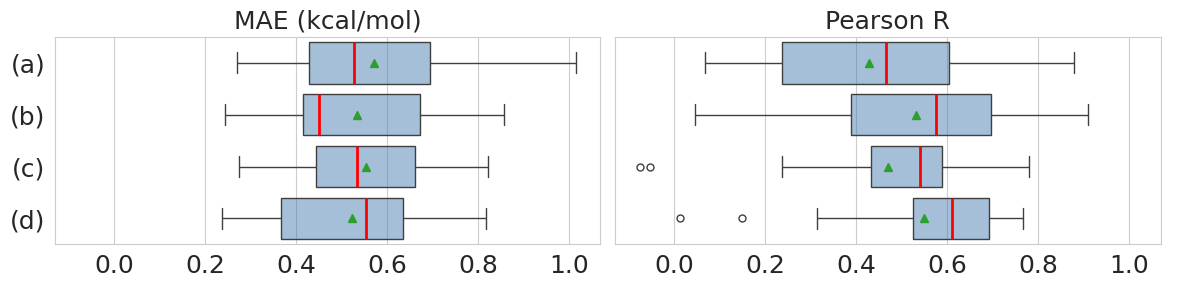

In [11]:
import seaborn as sns


with sns.axes_style("whitegrid"):
    g = sns.catplot(
        pd.DataFrame(results),
        x="value",
        col="metrics",
        y="representation class",
        kind="box",
        boxprops={"facecolor": (0.3, 0.5, 0.7, 0.5)},
        medianprops={"color": "r", "linewidth": 2},
        facet_kws=dict(despine=False),
        showmeans=True,
    )
    g.figure.set_size_inches(12, 3)
    g.tight_layout()
    g.set_xlabels("")
    g.set_ylabels("")
    g.set_yticklabels(["(a)", "(b)", "(c)", "(d)"], fontsize=18)
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_fontsize(18)
        if idx == 0:
            ax.set_title("MAE (kcal/mol)", fontsize=18)
        elif idx == 1:
            ax.set_title("Pearson R", fontsize=18)
    g.savefig("img/LORO-methods-ablation-study.png", dpi=300)

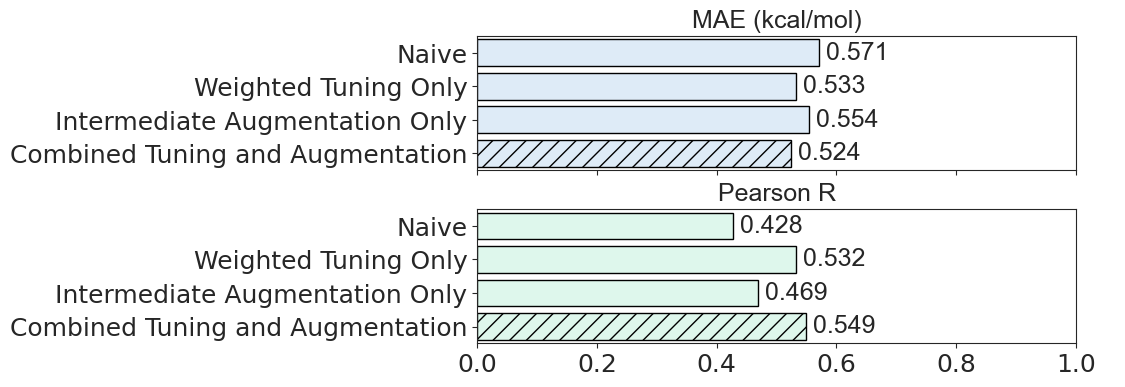

In [12]:
import seaborn as sns


with sns.axes_style("ticks"):
    g = sns.catplot(
        pd.DataFrame(results),
        x="value",
        row="metrics",
        y="representation class",
        kind="bar",
        errorbar=None,
        facet_kws=dict(despine=False, xlim=(0, 1)),
    )
    g.figure.set_size_inches(7, 4)
    g.tight_layout()
    g.set_xlabels("")
    g.set_ylabels("")
    g.set_yticklabels(
        [
            "Naive",
            "Weighted Tuning Only",
            "Intermediate Augmentation Only",
            "Combined Tuning and Augmentation",
        ],
        fontsize=18,
    )
    for idx, ((i, j, k), data_ijk) in enumerate(g.facet_data()):
        ax = g.facet_axis(i, j, k)
        for i, label in enumerate(ax.get_xticklabels()):
            label.set_fontsize(18)
        if idx == 0:
            for bar in ax.containers[0]:
                bar.set_edgecolor("black")
                bar.set_facecolor(color="#DEEBF7")
            else:
                bar.set_hatch("//")
            ax.set_title("MAE (kcal/mol)", fontsize=18, fontfamily="Arial")
        elif idx == 1:
            for bar in ax.containers[0]:
                bar.set_edgecolor("black")
                bar.set_facecolor(color="#DEF7EC")
            else:
                bar.set_hatch("//")
            ax.set_title("Pearson R", fontsize=18, fontfamily="Arial")
        ax.bar_label(
            container=ax.containers[0],
            fmt="%.3f",
            padding=5,
            fontfamily="Arial",
            fontsize=18,
        )
    g.savefig("img/LORO-methods-ablation-study.png", dpi=300)